In [96]:
with open("/content/drive/MyDrive/Colab Notebooks/Fundametnos De Datos/Cuento.txt", "r", encoding="utf-8") as archivo:
  Cuento = archivo.read()

In [97]:
print(Cuento[:500])

Cuentan que en un tiempo muy lejano el rey decidió pasear por sus dominios, que incluían una pequeña aldea en la que vivía un molinero junto con su bella hija. Al interesarse el rey por ella, el molinero mintió para darse importancia: "Además de bonita, es capaz de convertir la paja en oro hilándola con una rueca." El rey, francamente contento con dicha cualidad de la muchacha, no lo dudó un instante y la llevó con él a palacio.
Una vez en el castillo, el rey ordenó que condujesen a la hija del 


In [98]:
#funcion len:medir la longitud del dato
len(Cuento)

4076

In [99]:
Cuento = Cuento.lower()
Cuento = Cuento.replace(",", "")
Cuento = Cuento.replace(";", "")
Cuento = Cuento.replace(".", "")
Cuento = Cuento.replace(":", "")

In [100]:
len(Cuento)

3969

In [101]:
#Convertir mi discurso en palabras
palabras = Cuento.split()

In [102]:
print(palabras[:20])

['cuentan', 'que', 'en', 'un', 'tiempo', 'muy', 'lejano', 'el', 'rey', 'decidió', 'pasear', 'por', 'sus', 'dominios', 'que', 'incluían', 'una', 'pequeña', 'aldea', 'en']


In [103]:
import pandas as pd
import numpy as np

palabras_array=np.array(palabras)

In [104]:
len(palabras_array)

727

In [105]:
#analisis de longitud de palabras
longitudes = np.array([len(palabra)for palabra in palabras_array])

print("Promedio", np.mean(longitudes))
print("Mediana", np.median(longitudes))
print("Minimo", np.min(longitudes))
print("Maximo", np.max(longitudes))

Promedio 4.456671251719395
Mediana 4.0
Minimo 1
Maximo 17


In [106]:
#generar un dataframe

df = pd.DataFrame(
    {
        "palabra":palabras
    }
)
#del datafrmae, extraiga los 5 primeros resultados
df.head()

,palabra
0,cuentan
1,que
2,en
3,un
4,tiempo


In [107]:
#frecuencia de palabras
#value_counts() cuenta cuantas veces aparece un dato en el dataframe

frecuencias = df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
la       43
el       33
que      24
y        22
de       19
en       16
a        14
una      14
enano    12
paja     11
oro       9
por       9
lo        8
se        8
con       8
un        7
al        7
para      7
rey       7
más       7
Name: count, dtype: int64


In [108]:
#Creado im arrelo de palabras a eliminar (stopwords)

stopwords = ["el", "que", "en", "de", "del", "y", "la", "a","los","lo","al","un","te","\"","por","","una","él","es","para","más","su","se","tu","no","me","si","le","sus","cuando","sus","con","pero","esta"]

In [109]:
#Filtrando

df_limpio = df[~df["palabra"].isin(stopwords)]

In [110]:
frecuencias = df_limpio["palabra"].value_counts()
print(frecuencias.head(40))

palabra
enano           12
paja            11
oro              9
rey              7
molinero         5
había            4
zis-zas          4
muchacha         4
nombre           4
apareció         4
hija             4
nunca            3
preguntó         3
habitación       3
noche            3
puedes           3
hasta            3
vez              3
estaba           3
día              3
favor            2
desconsolada     2
lloró            2
ser              2
repleta          2
hilaba           2
ahora            2
duende           2
rueca            2
"tienes          2
iba              2
convirtiendo     2
reina            2
las              2
mi               2
como             2
mujer            2
pequeña          2
anterior         2
niño             2
Name: count, dtype: int64


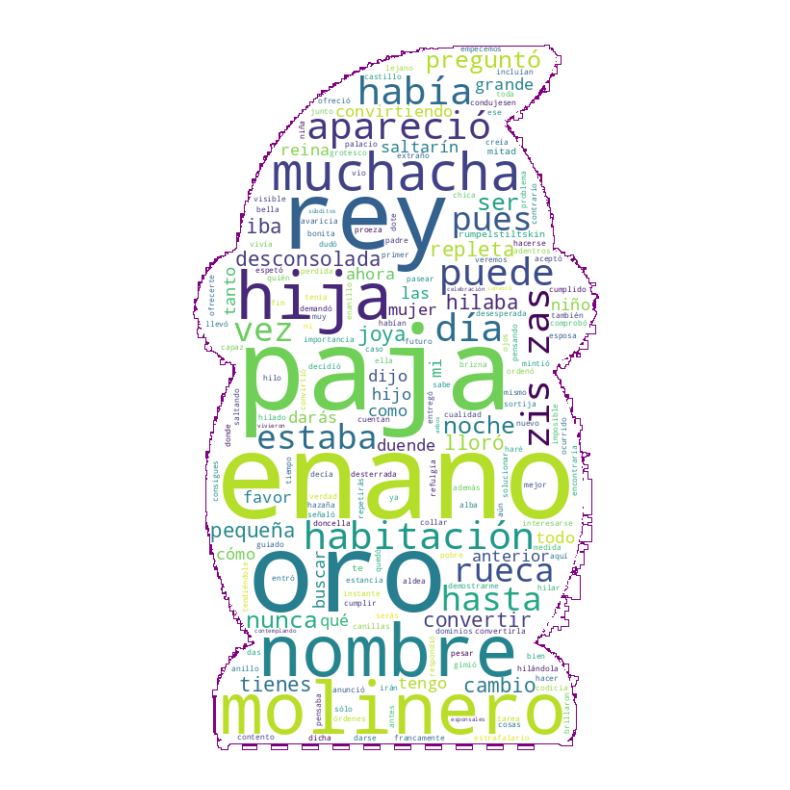

In [111]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

mask_image = np.array(Image.open("/content/drive/MyDrive/Colab Notebooks/Fundametnos De Datos/vectores-de-iconos-enanos-cerámica-plana-icono-enano-contorno-vectorial-para-diseño-web-aislado-en-color-fondo-blanco-plano-273207038.webp"))

texto_limpio = " ".join(df_limpio["palabra"])

nube = WordCloud(
    background_color="white",
    mask=mask_image,
    contour_width=1,
    contour_color="purple"
).generate(texto_limpio)

plt.figure(figsize=(10, 10))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()